# Comparación de estrategias de ecualización

**Duración estimada:** 70 minutos

## Objetivo

En este cuaderno vas a comparar varias formas de mejorar contraste sobre la misma imagen de trabajo. La meta es pasar de la ecualización básica a una lectura más crítica de qué conviene hacer y qué conviene evitar.

## Resultados de aprendizaje

Al final vas a poder:

- comparar ecualización en grises, por canal, sobre `V` y con `CLAHE`;
- discutir cuándo una mejora conserva mejor el color;
- usar histogramas y medidas simples para sostener una decisión;
- elegir una estrategia razonable para un pipeline posterior.


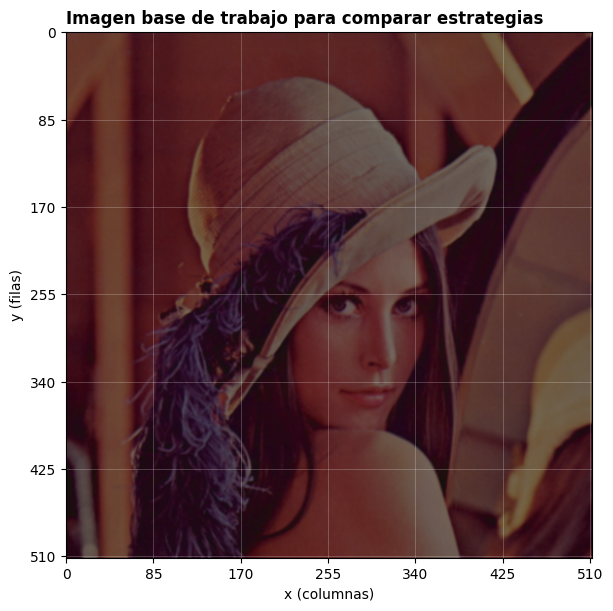

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


CARPETA_IMAGENES = Path("Imagenes")


def abrir_imagen_bgr(nombre_archivo):
    """Abre una imagen en color usando el orden BGR de OpenCV."""
    ruta = CARPETA_IMAGENES / nombre_archivo
    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)
    if imagen_bgr is None:
        raise FileNotFoundError(f"No pude abrir la imagen: {ruta}")
    return imagen_bgr


def abrir_imagen_rgb(nombre_archivo):
    """Abre una imagen y la convierte a RGB para mostrarla con Matplotlib."""
    imagen_bgr = abrir_imagen_bgr(nombre_archivo)
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    return imagen_rgb


def preparar_eje_imagen(eje, imagen, titulo, mapa=None):
    """Muestra una imagen conservando ejes y coordenadas visibles."""
    eje.imshow(imagen, cmap=mapa)
    eje.set_title(titulo, loc="left", fontweight="bold")
    eje.set_xlabel("x (columnas)")
    eje.set_ylabel("y (filas)")

    if imagen.ndim == 2:
        alto, ancho = imagen.shape
    else:
        alto, ancho = imagen.shape[:2]

    paso_x = max(50, ancho // 6)
    paso_y = max(50, alto // 6)
    eje.set_xticks(np.arange(0, ancho + 1, paso_x))
    eje.set_yticks(np.arange(0, alto + 1, paso_y))
    eje.grid(color="white", alpha=0.25, linewidth=0.6)


def mostrar_una_imagen(imagen, titulo, mapa=None, tamano=(8, 6)):
    fig, eje = plt.subplots(figsize=tamano, constrained_layout=True)
    preparar_eje_imagen(eje, imagen, titulo, mapa)
    plt.show()


def mostrar_varias_imagenes(imagenes, titulos, mapas=None, tamano=(15, 5)):
    if mapas is None:
        mapas = [None] * len(imagenes)

    fig, ejes = plt.subplots(1, len(imagenes), figsize=tamano, constrained_layout=True)
    if len(imagenes) == 1:
        ejes = [ejes]

    for eje, imagen, titulo, mapa in zip(ejes, imagenes, titulos, mapas):
        preparar_eje_imagen(eje, imagen, titulo, mapa)

    plt.show()


def mostrar_histograma_gris(imagen_gris, titulo):
    histograma, bordes = np.histogram(imagen_gris.ravel(), bins=256, range=(0, 256))
    plt.figure(figsize=(9, 4))
    plt.plot(bordes[:-1], histograma, color="black")
    plt.title(titulo, loc="left", fontweight="bold")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de píxeles")
    plt.grid(alpha=0.3)
    plt.xlim(0, 255)
    plt.show()


def mostrar_histogramas_bgr(imagen_bgr, titulo_general):
    nombres = ["azul", "verde", "rojo"]
    colores = ["tab:blue", "tab:green", "tab:red"]
    fig, ejes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

    for indice in range(3):
        histograma = cv2.calcHist([imagen_bgr], [indice], None, [256], [0, 256]).ravel()
        ejes[indice].plot(histograma, color=colores[indice])
        ejes[indice].set_title(f"Canal {nombres[indice]}", loc="left", fontweight="bold")
        ejes[indice].set_xlabel("Intensidad")
        ejes[indice].set_ylabel("Frecuencia")
        ejes[indice].grid(alpha=0.25)

    fig.suptitle(titulo_general, x=0.01, ha="left", fontweight="bold")
    plt.show()

imagen_bgr = abrir_imagen_bgr("valeria.png")


def construir_version_apagada(imagen_bgr):
    imagen_con_menos_contraste = cv2.convertScaleAbs(imagen_bgr, alpha=0.58, beta=-18)
    velo_gris = np.full_like(imagen_con_menos_contraste, 28)
    imagen_con_menos_contraste = cv2.addWeighted(imagen_con_menos_contraste, 0.88, velo_gris, 0.12, 0)
    imagen_con_menos_contraste = cv2.GaussianBlur(imagen_con_menos_contraste, (3, 3), 0)
    return imagen_con_menos_contraste


imagen_apagada_bgr = construir_version_apagada(imagen_bgr)
imagen_apagada_rgb = cv2.cvtColor(imagen_apagada_bgr, cv2.COLOR_BGR2RGB)

mostrar_una_imagen(imagen_apagada_rgb, "Imagen base de trabajo para comparar estrategias")


## 1. Punto de partida: histogramas y problema visual

Antes de comparar transformaciones, conviene dejar claro qué estamos corrigiendo. En esta imagen la información tonal está comprimida. Eso no significa que cualquier ecualización sea buena: algunas recuperan contraste pero deforman el color o exageran diferencias poco útiles.


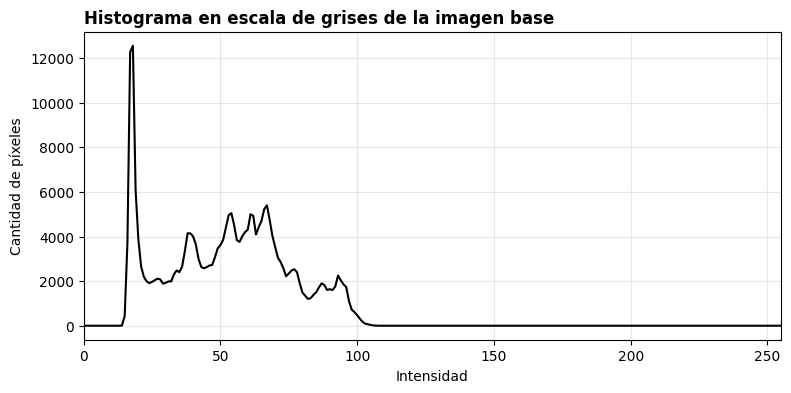

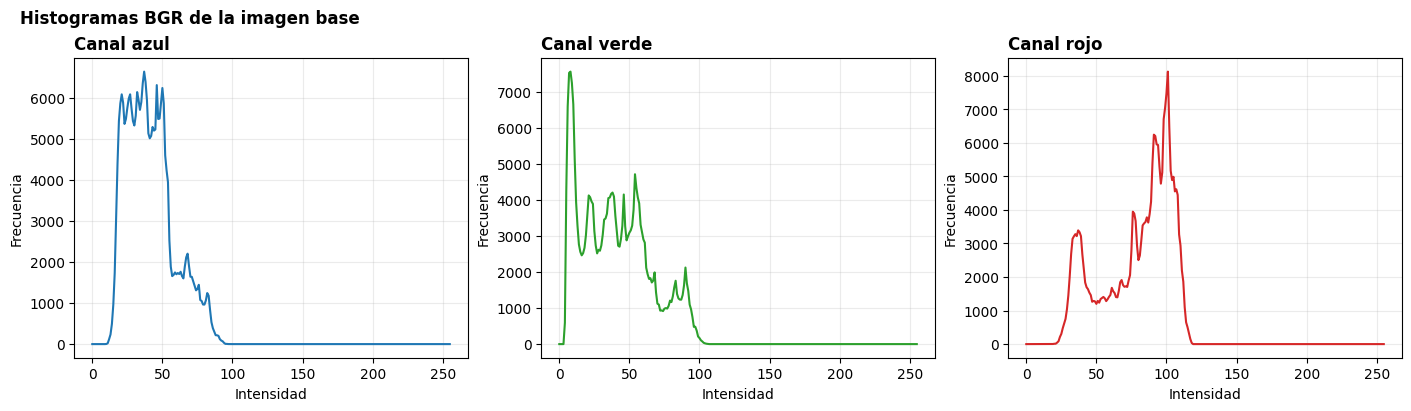

In [2]:
imagen_apagada_gris = cv2.cvtColor(imagen_apagada_bgr, cv2.COLOR_BGR2GRAY)

mostrar_histograma_gris(imagen_apagada_gris, "Histograma en escala de grises de la imagen base")
mostrar_histogramas_bgr(imagen_apagada_bgr, "Histogramas BGR de la imagen base")


## 2. Cuatro estrategias diferentes

Vamos a construir cuatro salidas:

1. ecualización global en grises;
2. ecualización de cada canal `BGR` por separado;
3. ecualización del canal `V` en `HSV`;
4. `CLAHE` sobre el canal `V`.

Las vamos a implementar paso a paso para que el código sea fácil de seguir.


In [3]:
gris_ecualizada = cv2.equalizeHist(imagen_apagada_gris)

imagen_ecualizada_por_canal = imagen_apagada_bgr.copy()
for indice_canal in range(3):
    canal = imagen_apagada_bgr[:, :, indice_canal]
    canal_ecualizado = cv2.equalizeHist(canal)
    imagen_ecualizada_por_canal[:, :, indice_canal] = canal_ecualizado

imagen_hsv = cv2.cvtColor(imagen_apagada_bgr, cv2.COLOR_BGR2HSV)
imagen_hsv_ecualizada = imagen_hsv.copy()
imagen_hsv_ecualizada[:, :, 2] = cv2.equalizeHist(imagen_hsv_ecualizada[:, :, 2])
imagen_ecualizada_hsv_bgr = cv2.cvtColor(imagen_hsv_ecualizada, cv2.COLOR_HSV2BGR)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
imagen_hsv_clahe = imagen_hsv.copy()
imagen_hsv_clahe[:, :, 2] = clahe.apply(imagen_hsv_clahe[:, :, 2])
imagen_clahe_bgr = cv2.cvtColor(imagen_hsv_clahe, cv2.COLOR_HSV2BGR)


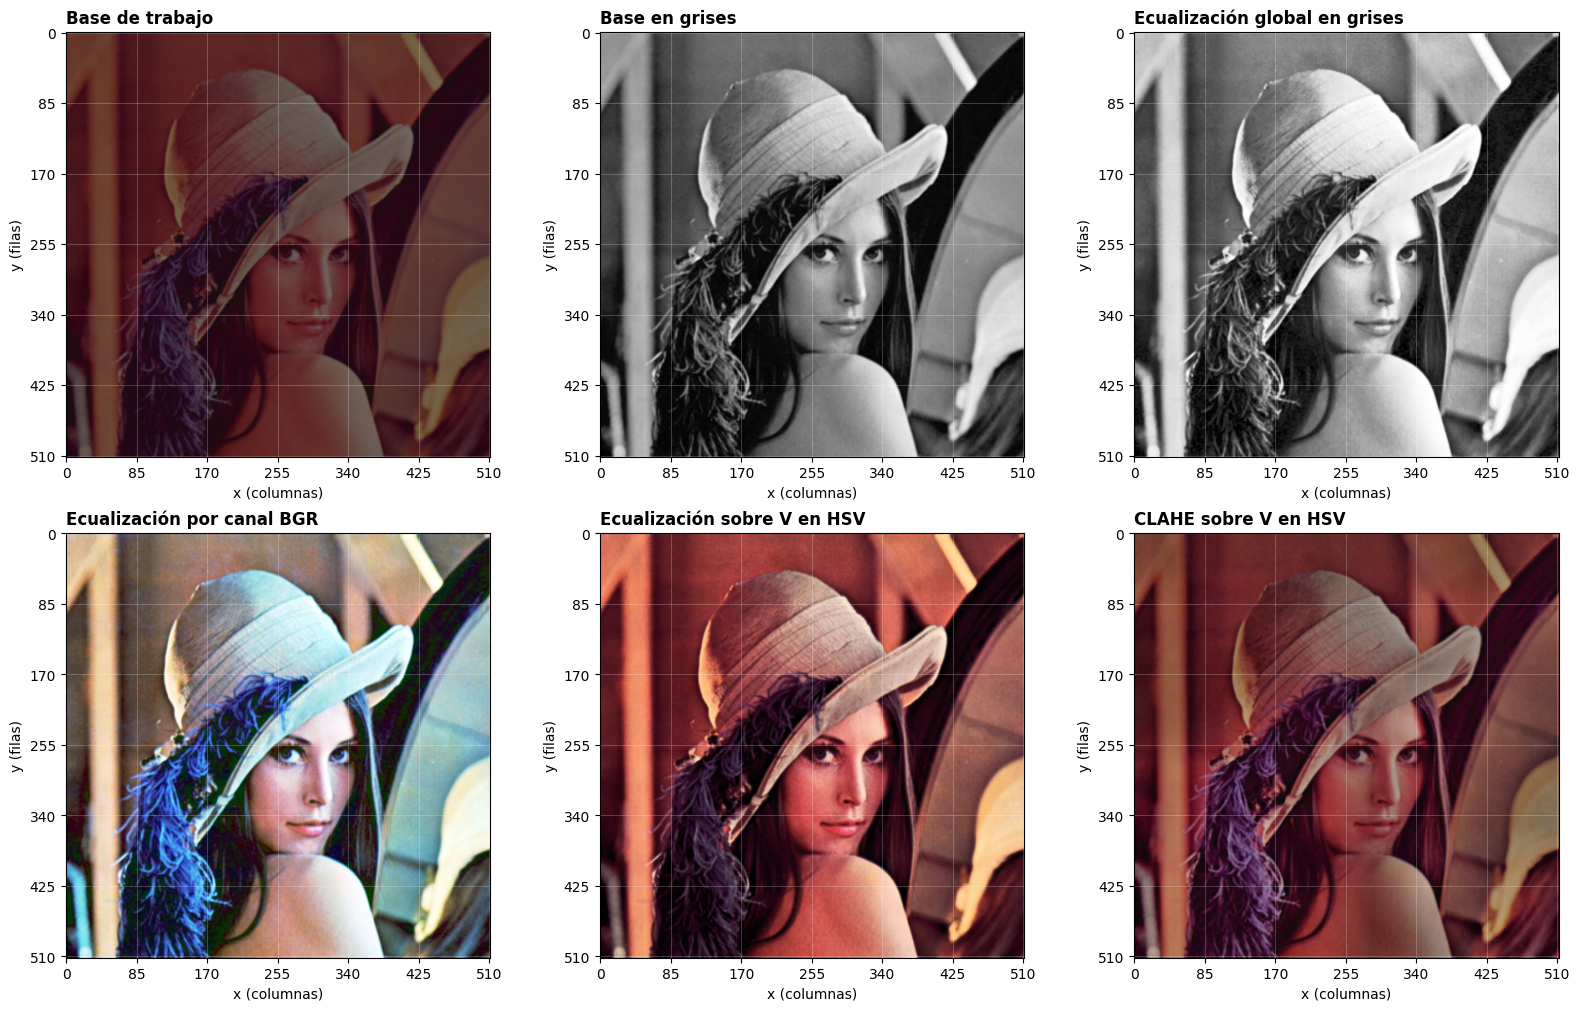

In [4]:
fig, ejes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)

preparar_eje_imagen(ejes[0, 0], imagen_apagada_rgb, "Base de trabajo")
preparar_eje_imagen(ejes[0, 1], imagen_apagada_gris, "Base en grises", "gray")
preparar_eje_imagen(ejes[0, 2], gris_ecualizada, "Ecualización global en grises", "gray")

preparar_eje_imagen(
    ejes[1, 0],
    cv2.cvtColor(imagen_ecualizada_por_canal, cv2.COLOR_BGR2RGB),
    "Ecualización por canal BGR",
)
preparar_eje_imagen(
    ejes[1, 1],
    cv2.cvtColor(imagen_ecualizada_hsv_bgr, cv2.COLOR_BGR2RGB),
    "Ecualización sobre V en HSV",
)
preparar_eje_imagen(
    ejes[1, 2],
    cv2.cvtColor(imagen_clahe_bgr, cv2.COLOR_BGR2RGB),
    "CLAHE sobre V en HSV",
)

plt.show()


In [5]:
desvio_base = imagen_apagada_gris.std()
desvio_grises = gris_ecualizada.std()
desvio_hsv = cv2.cvtColor(imagen_ecualizada_hsv_bgr, cv2.COLOR_BGR2GRAY).std()
desvio_clahe = cv2.cvtColor(imagen_clahe_bgr, cv2.COLOR_BGR2GRAY).std()

print(f"Desvío estándar en grises (base): {desvio_base:.2f}")
print(f"Desvío estándar en grises (ecualización global): {desvio_grises:.2f}")
print(f"Desvío estándar en grises (ecualización sobre V): {desvio_hsv:.2f}")
print(f"Desvío estándar en grises (CLAHE sobre V): {desvio_clahe:.2f}")


Desvío estándar en grises (base): 22.84
Desvío estándar en grises (ecualización global): 72.90
Desvío estándar en grises (ecualización sobre V): 60.25
Desvío estándar en grises (CLAHE sobre V): 35.27


## Cierre

Este cuaderno no busca que memorices una “mejor” receta universal. Busca que puedas argumentar por qué una estrategia conserva mejor color, por qué otra exagera demasiado y cuál conviene elegir para el objetivo que tengas.

**Actividad breve**

Elegí una de las cuatro salidas y escribí por qué sería tu candidata para entrar a un pipeline de restauración.
